# Projeto Prático de Machine Learning

## Objetivo
Desenvolver um projeto completo de Machine Learning aplicando os conceitos estudados ao longo do curso.

---

## Descrição

Você deverá construir um pipeline de Machine Learning, passando por todas as etapas necessárias:

- Análise dos dados  
- Pré-processamento  
- Treinamento de um modelo  
- Avaliação dos resultados  
- Interpretação dos resultados  

---

## Escolha do problema

Escolha um dos tipos abaixo:

### 1) Classificação
Exemplo: prever uma classe (spam/não spam, tipo de planta, etc.)

### 2) Regressão
Exemplo: prever um valor numérico (preço, temperatura, etc.)

### 3) Clustering
Exemplo: agrupar dados semelhantes (segmentação de clientes)

---

## Etapas obrigatórias

### 1) Análise dos dados
- Descreva o dataset  
- Identifique padrões, distribuições e possíveis problemas  

---

### 2) Pré-processamento
- Trate valores ausentes (se houver)  
- Realize normalização ou padronização  
- Codifique variáveis categóricas (se necessário)  
- Compare dados antes e depois do pré-processamento  

---

### 3) Modelagem
- Escolha um algoritmo adequado ao problema  
- Treine o modelo  
- Justifique sua escolha  

---

### 4) Avaliação

Dependendo do problema:

* Para classificação:
  - Percentual de acertos (quantos exemplos o modelo acertou)
  - Análise dos erros (quais tipos de exemplos foram mais difíceis)
  - Matriz de confusão (se desejar, como ferramenta visual)

* Para regressão:
  - Comparação entre valores reais e valores previstos
  - Análise visual dos erros (diferença entre o valor real e o previsto)
  - Discussão sobre se o modelo está “próximo” ou “longe” dos valores reais

* Para clustering:
  - Visualização dos grupos formados
  - Análise se os grupos fazem sentido na prática
  - Interpretação dos padrões encontrados

---

### 5) Conclusões
Responda:

- O modelo teve bom desempenho?  
- O pré-processamento influenciou o resultado?  
- O modelo seria útil em um cenário real?  

---

## Entrega

- Notebook (.ipynb) completo  
- Código organizado  
- Gráficos e análises  
- Comentários explicando as decisões  

---

## Importante
Não foque apenas no código.  
Explique seu raciocínio em cada etapa do projeto.

# Projeto de Classificação e Agrupamento: Diagnóstico Cardiovascular

## Visão Geral do Projeto

Este notebook apresenta um pipeline completo de Ciência de Dados aplicado ao problema de **diagnóstico de doenças cardiovasculares**. O objetivo central é construir um modelo capaz de prever se um paciente possui ou não uma patologia cardíaca, utilizando atributos clínicos como idade, pressão arterial, colesterol, entre outros.

### Abordagem Adotada

O projeto combina **duas técnicas de Machine Learning**:

1. **Aprendizado Não Supervisionado (K-Means Clustering):** utilizado como ferramenta de engenharia de atributos. O K-Means segmenta os pacientes em perfis de risco com base em suas características clínicas, gerando uma nova feature (`Perfil_KMeans`) que enriquece o conjunto de dados original.

2. **Aprendizado Supervisionado (K-Nearest Neighbors - KNN):** utilizado como classificador final para prever a presença ou ausência de doença cardíaca. O KNN se beneficia da informação estrutural fornecida pelo clustering.

### Por que esta abordagem híbrida?

A ideia é que o agrupamento revele padrões latentes nos dados que o classificador sozinho poderia não captar. Por exemplo, pacientes com perfis clínicos semelhantes podem ser agrupados em clusters que representam níveis de risco distintos, e essa informação adicional pode melhorar a capacidade preditiva do modelo.

### Estrutura do Notebook

| Seção | Descrição |
|-------|-----------|
| 1. Aquisição e Exploração | Carregamento do dataset, análise estatística e visual |
| 2. Pré-processamento | Limpeza, padronização e engenharia de features |
| 3. Agrupamento (K-Means) | Segmentação em perfis de risco |
| 4. Modelagem (KNN) | Treinamento e otimização do classificador |
| 5. Avaliação | Métricas, matrizes de confusão e comparações |
| 6. Conclusões | Interpretação final e aplicabilidade |

In [ ]:
# ============================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modelagem
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# Métricas de avaliação
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, precision_recall_fscore_support,
                             accuracy_score)

# Configuração visual global
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Todas as bibliotecas importadas com sucesso.")

Todas as bibliotecas importadas com sucesso.


---

## 1. Aquisição e Exploração de Dados

### 1.1 Sobre o Dataset

O dataset utilizado é o **Heart Disease Dataset**, disponibilizado publicamente no GitHub e originalmente proveniente do repositório UCI Machine Learning. Ele contém registros clínicos de 303 pacientes atendidos em instituições de saúde.

**Cada linha representa um paciente**, e **cada coluna representa um atributo clínico** coletado durante exames médicos. A variável alvo (`target`) indica:

- `0` → Paciente **saudável** (sem doença cardíaca detectada)
- `1` → Paciente **com doença cardíaca** detectada

### Dicionário de Variáveis

| Variável | Descrição | Tipo |
|----------|-----------|------|
| `age` | Idade do paciente em anos | Numérica contínua |
| `sex` | Sexo biológico (1 = masculino, 0 = feminino) | Categórica binária |
| `cp` | Tipo de dor torácica (0 a 3) | Categórica ordinal |
| `trestbps` | Pressão arterial em repouso (mm Hg) | Numérica contínua |
| `chol` | Colesterol sérico (mg/dl) | Numérica contínua |
| `fbs` | Glicemia em jejum > 120 mg/dl (1 = sim, 0 = não) | Categórica binária |
| `restecg` | Resultados do eletrocardiograma em repouso (0 a 2) | Categórica ordinal |
| `thalach` | Frequência cardíaca máxima atingida | Numérica contínua |
| `exang` | Angina induzida por exercício (1 = sim, 0 = não) | Categórica binária |
| `oldpeak` | Depressão do segmento ST induzida por exercício | Numérica contínua |
| `slope` | Inclinação do segmento ST no pico do exercício | Categórica ordinal |
| `ca` | Número de vasos principais coloridos por fluoroscopia (0 a 3) | Numérica discreta |
| `thal` | Resultado do teste de talassemia (0 a 3) | Categórica ordinal |
| `target` | Diagnóstico de doença cardíaca (0 = não, 1 = sim) | **Variável alvo** |

### Por que este dataset?

Este dataset é ideal para o projeto porque:
1. Possui tamanho moderado (303 amostras), adequado para algoritmos como KNN
2. Combina variáveis numéricas e categóricas, exigindo pré-processamento
3. Tem relevância clínica real - doenças cardiovasculares são a principal causa de morte global
4. As classes estão razoavelmente balanceadas, evitando viés extremo

In [ ]:
# ============================================================
# 1.1 CARREGAMENTO DO DATASET
# ============================================================
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)
TARGET = 'target'

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas\n")
print("Primeiras 5 linhas:")
display(df.head())

Dataset carregado com sucesso!
Dimensões: 303 linhas × 14 colunas

Primeiras 5 linhas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 1.2 Análise Estrutural do Dataset

Antes de qualquer modelagem, precisamos verificar pontos fundamentais:
- **Existem valores ausentes?** Valores faltantes podem distorcer o treinamento do modelo.
- **Existem duplicatas?** Linhas duplicadas inflam artificialmente o dataset e podem causar overfitting.
- **Quais são os tipos de dados?** Isso determina quais transformações serão necessárias.
- **Qual a distribuição estatística de cada variável?** Outliers e distribuições assimétricas podem impactar algoritmos baseados em distância como o KNN.

In [ ]:
# ============================================================
# 1.2 ANÁLISE ESTRUTURAL
# ============================================================

print("=" * 60)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 60)
print(f"\nQuantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")
print(f"\nValores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")
print(f"\nQuantidade de linhas duplicadas: {df.duplicated().sum()}")
print(f"\nTipos de dados:")
print(df.dtypes)

INFORMAÇÕES GERAIS DO DATASET

Quantidade de linhas: 303
Quantidade de colunas: 14

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total de valores ausentes: 0

Quantidade de linhas duplicadas: 1

Tipos de dados:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
# ============================================================
# 1.3 ESTATÍSTICAS DESCRITIVAS
# ============================================================

print("-=" * 30)
print("ESTATÍSTICAS DESCRITIVAS")
print("=-" * 30)
display(df.describe().round(2))

-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
ESTATÍSTICAS DESCRITIVAS
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


### Interpretação das Estatísticas Descritivas

Analisando a tabela acima, podemos extrair informações valiosas:

**Idade (`age`):**
- Média de ~54 anos, variando de 29 a 77 anos.
- A maioria dos pacientes está na faixa dos 40 a 60 anos, o que é esperado para um dataset de cardiologia.

**Pressão arterial (`trestbps`):**
- Média de ~131 mm Hg (levemente acima do normal de 120 mm Hg).
- O valor máximo de 200 mm Hg indica possíveis casos de hipertensão severa.
- O desvio padrão de ~17 indica variabilidade moderada.

**Colesterol (`chol`):**
- Média de ~246 mg/dl, acima do limite recomendado de 200 mg/dl.
- Valor máximo de 564 mg/dl é um possível **outlier** que merece atenção.
- Isso sugere que a população do estudo tem tendência a hipercolesterolemia.

**Frequência cardíaca máxima (`thalach`):**
- Média de ~149 bpm com range de 71 a 202 bpm.
- Valores baixos podem indicar capacidade cardiovascular comprometida.

**Oldpeak:**
- Mediana (50%) de 0.8, mas o valor máximo é 6.2.
- Distribuição claramente assimétrica à direita (média > mediana), indicando que a maioria dos pacientes tem baixa depressão ST, mas há outliers com valores altos.

**Observação importante sobre as escalas:**
As variáveis possuem escalas muito diferentes - `chol` varia de 126 a 564, enquanto `sex` é binário (0 ou 1). Essa diferença de magnitude é **problemática para o KNN**, que calcula distâncias Euclidianas. A **padronização (StandardScaler) será essencial** na etapa de pré-processamento.

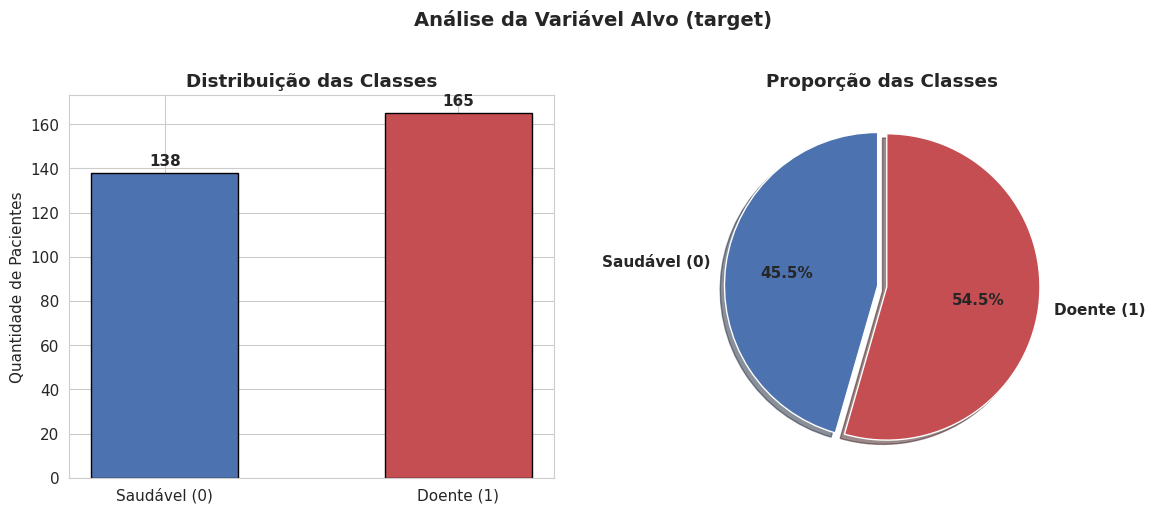

Classe 0 (Saudável): 138 pacientes (45.5%)
Classe 1 (Doente):   165 pacientes (54.5%)
Razão entre classes:  1:1.20


In [ ]:
# ================================================================
# 1.4 DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem - garantir a ordem correta
counts = df[TARGET].value_counts().sort_index()  # Ordem: 0, 1
colors = ['#4C72B0', '#C44E52']  # Azul = Saudável, Vermelho = Doente

# Gráfico de barras
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Saudável (0)', 'Doente (1)'])
axes[0].set_title('Distribuição das Classes', fontweight='bold')
axes[0].set_ylabel('Quantidade de Pacientes')

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Gráfico de pizza - ORDEM CORRETA
# Agora counts.index está [0, 1] e counts.values está [138, 165]
axes[1].pie(counts.values,
            labels=['Saudável (0)', 'Doente (1)'],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.03, 0.03),
            shadow=True,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Análise da Variável Alvo (target)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estatísticas
saudaveis = counts[0]
doentes = counts[1]
total = len(df)
print(f"Classe 0 (Saudável): {saudaveis} pacientes ({saudaveis/total*100:.1f}%)")
print(f"Classe 1 (Doente):   {doentes} pacientes ({doentes/total*100:.1f}%)")
print(f"Razão entre classes:  1:{doentes/saudaveis:.2f}")

## Interpretação da Distribuição das Classes

O gráfico acima revela que as classes estão **razoavelmente balanceadas** - aproximadamente **45.5% dos pacientes são saudáveis** (classe 0) e **54.5% possuem doença cardíaca** (classe 1).

**Por que isso é importante?**

- Em datasets **desbalanceados** (ex: 95% vs 5%), o modelo pode simplesmente prever sempre a classe majoritária e ainda assim ter alta acurácia - mas seria inútil na prática.
- Como nosso dataset está próximo de 50/50, a **acurácia é uma métrica confiável** para avaliar o desempenho.
- Não há necessidade de técnicas de balanceamento como SMOTE ou undersampling.
- A proporção é clinicamente realista: em muitas populações de risco cardiovascular, a prevalência de doença cardíaca pode chegar a 50% ou mais.

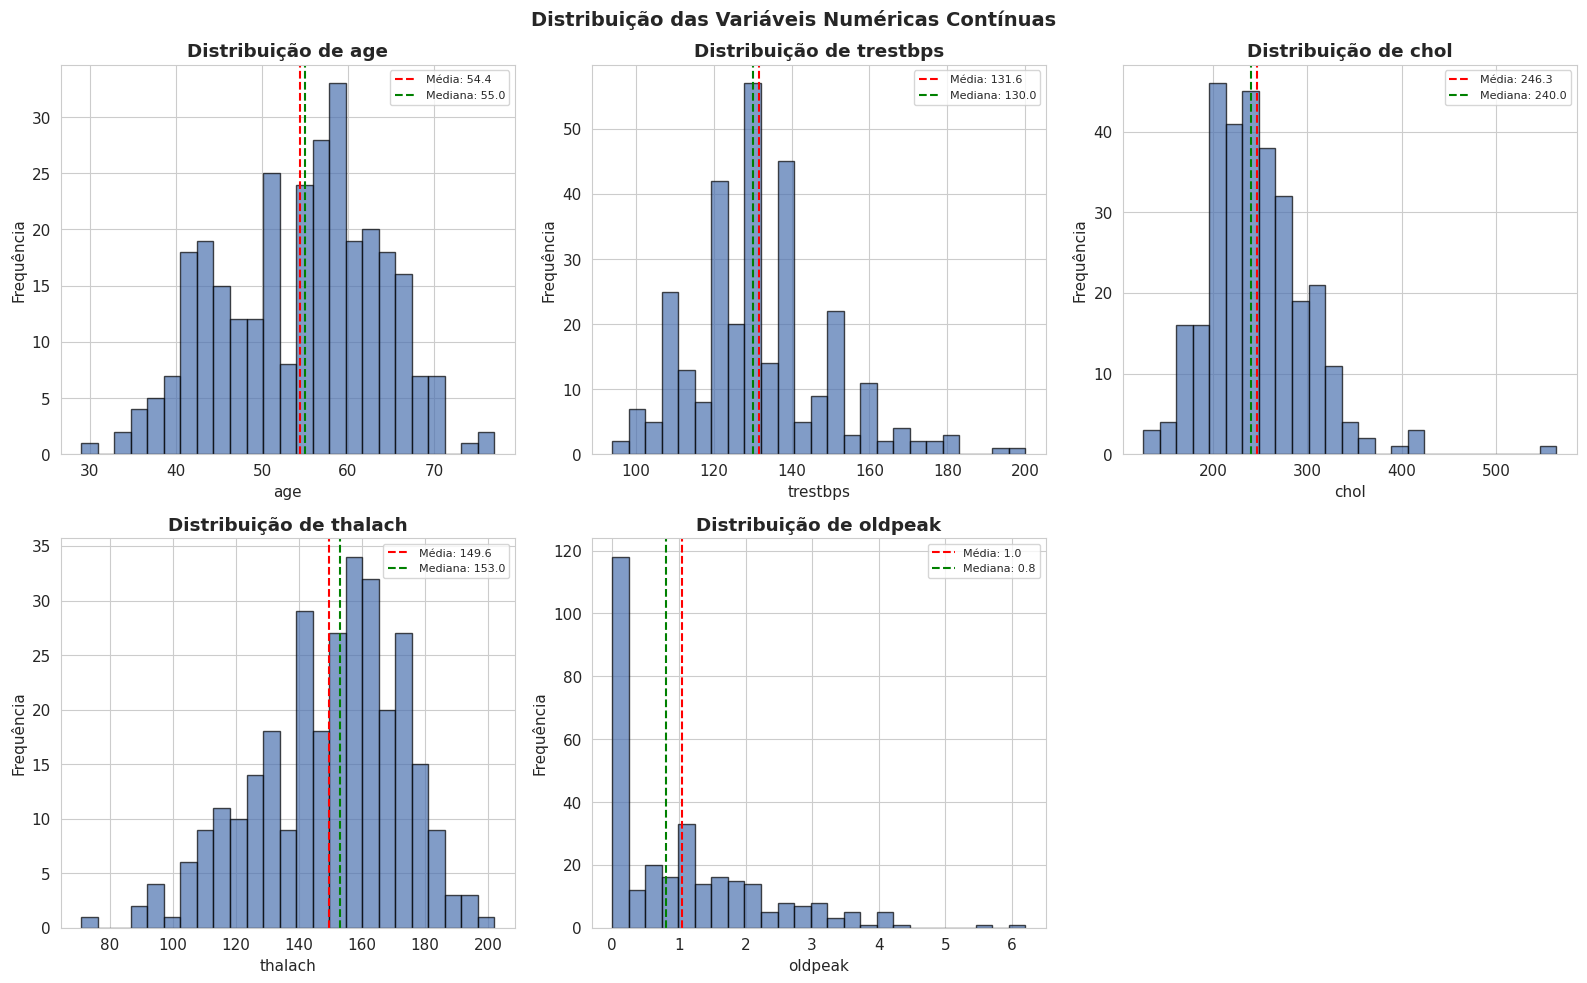

In [ ]:
# ================================================================
# 1.5 DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS
# ================================================================

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=25, color='#4C72B0', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Média: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Mediana: {df[col].median():.1f}')
    axes[i].set_title(f'Distribuição de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

# Remover subplot vazio
axes[5].set_visible(False)

plt.suptitle('Distribuição das Variáveis Numéricas Contínuas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretação das Distribuições

Analisando os histogramas:

- **`age`**: Distribuição aproximadamente normal centrada em ~54 anos. Não há valores extremos preocupantes.

- **`trestbps`**: Levemente assimétrica à direita. A maioria dos pacientes tem pressão entre 120-140 mm Hg. Alguns valores acima de 170 podem ser outliers, mas são clinicamente plausíveis (hipertensão severa).

- **`chol`**: Distribuição com cauda à direita. O valor de 564 mg/dl é um outlier extremo, mas optei por **mantê-lo** pois pode representar um caso real de hipercolesterolemia severa — informação relevante para o diagnóstico.

- **`thalach`**: Distribuição levemente assimétrica à esquerda. Pacientes com frequência cardíaca máxima baixa podem ter capacidade cardiovascular limitada.

- **`oldpeak`**: Fortemente assimétrica à direita — a maioria dos pacientes tem valores próximos de 0. Valores altos (>4) são raros e indicam depressão ST significativa durante exercício.

**Implicação para o modelo:** As distribuições assimétricas e as escalas diferentes reforçam a necessidade de **padronização (StandardScaler)** antes de alimentar o KNN.

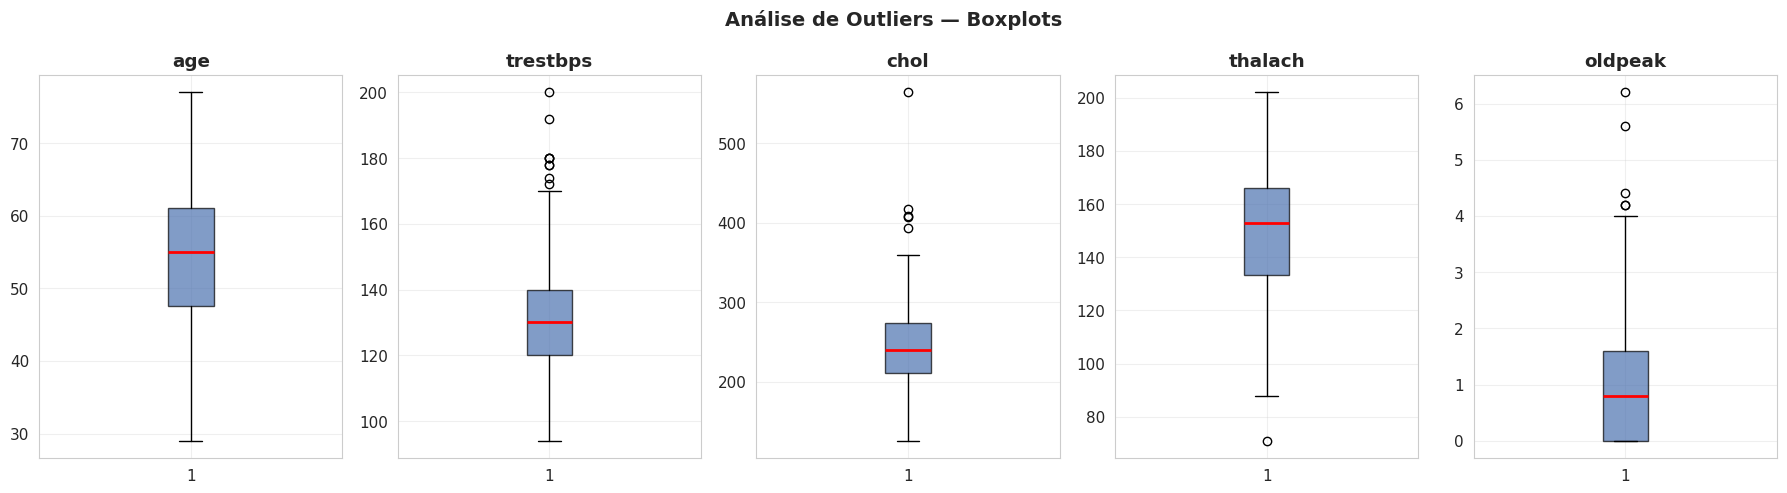

In [ ]:
# ================================================================
# 1.6 ANÁLISE DE OUTLIERS (BOXPLOTS)
# ================================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                         boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Análise de Outliers — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretação dos Boxplots

Os boxplots confirmam o que observamos nos histogramas:

- **`chol`**: Apresenta outliers acima de ~370 mg/dl, com um caso extremo próximo de 564. Esses são clinicamente possíveis e podem ser pacientes de alto risco.

- **`trestbps`**: Alguns outliers acima de 170 mm Hg (hipertensão severa).

- **`oldpeak`**: Outliers acima de ~4, representando depressão ST significativa.

- **`age`** e **`thalach`**: Sem outliers significativos.

**Decisão:** Optamos por **não remover outliers** neste projeto, pois em contexto médico, valores extremos frequentemente representam os casos mais graves — exatamente os pacientes que o modelo precisa identificar corretamente.

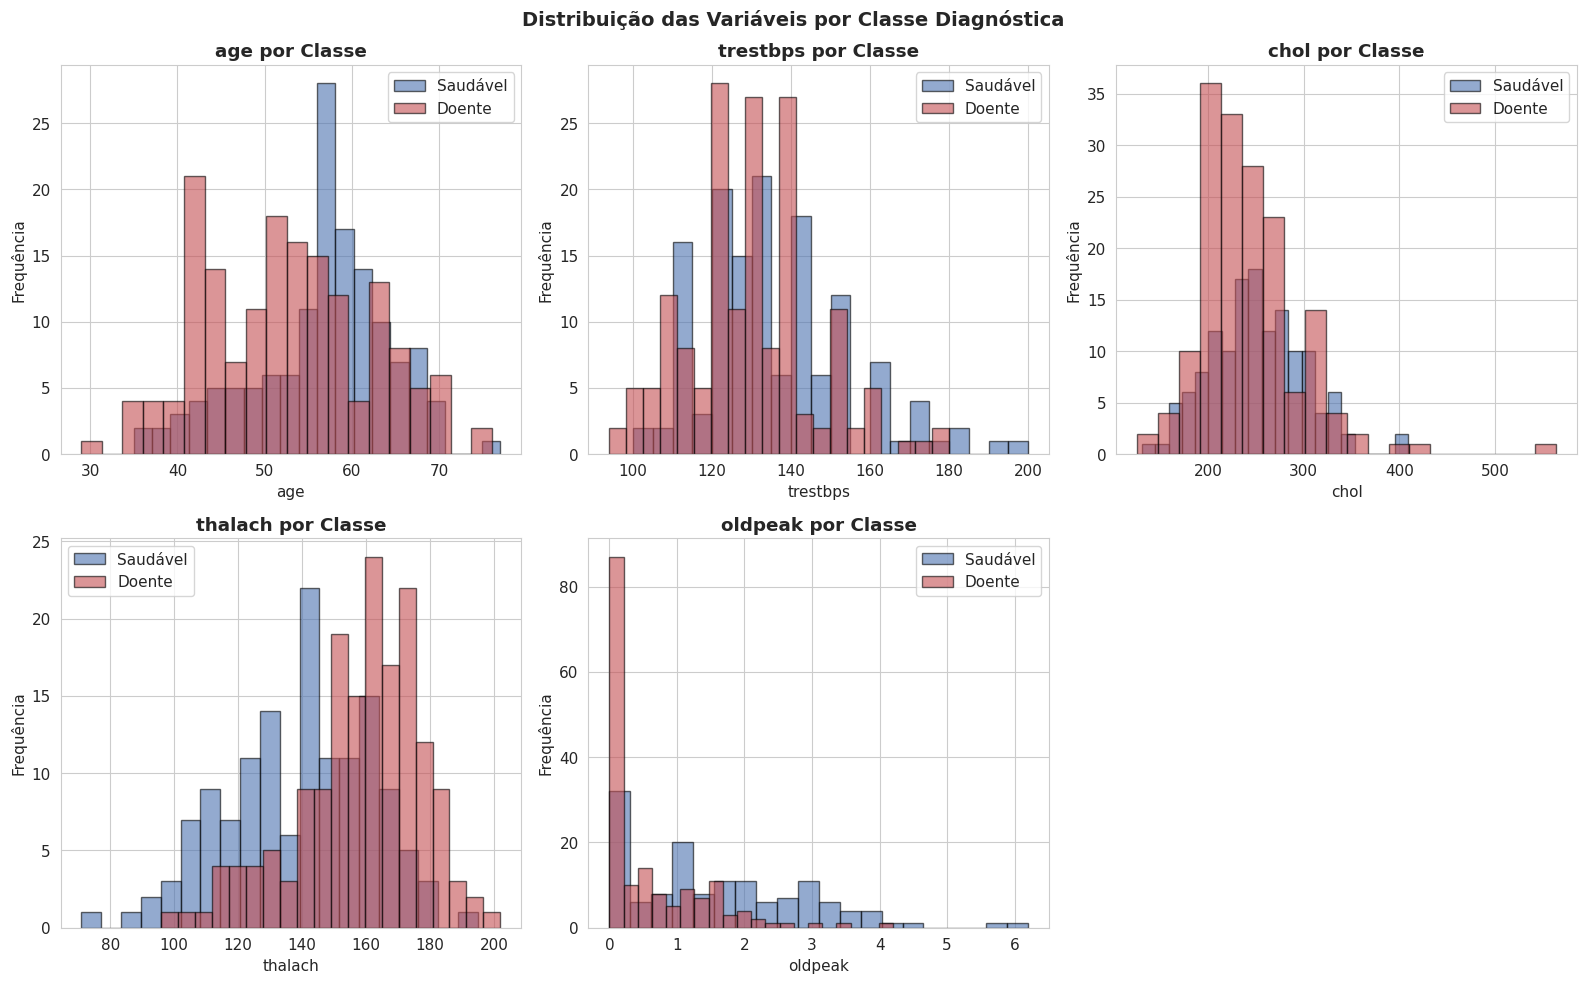

In [ ]:
# ================================================================
# 1.7 DISTRIBUIÇÃO DAS FEATURES POR CLASSE
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for target_val, color, label in [(0, '#4C72B0', 'Saudável'), (1, '#C44E52', 'Doente')]:
        subset = df[df[TARGET] == target_val]
        axes[i].hist(subset[col], bins=20, alpha=0.6, color=color,
                     label=label, edgecolor='black')
    axes[i].set_title(f'{col} por Classe', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

axes[5].set_visible(False)
plt.suptitle('Distribuição das Variáveis por Classe Diagnóstica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretação da Distribuição por Classe

Os histogramas sobrepostos revelam quais variáveis **separam melhor** as duas classes:

- **`thalach` (frequência cardíaca máxima):** Excelente separação. Pacientes doentes tendem a ter frequência cardíaca máxima **mais alta**. O pico dos doentes está em ~160 bpm, enquanto os saudáveis ficam em ~140 bpm.

- **`oldpeak`:** Boa separação. Pacientes **doentes** tendem a ter `oldpeak` **mais alto** (maior depressão do segmento ST durante exercício). Isso é clinicamente esperado: quanto maior a depressão do ST, maior o indício de isquemia miocárdica.

- **`age`:** Separação moderada. Pacientes doentes tendem a ser ligeiramente **mais jovens** neste dataset — comportamento que pode parecer contraintuitivo, mas reflete um viés de amostragem: populações mais jovens submetidas a exames cardiológicos tendem a representar casos de risco identificados precocemente.

- **`chol` e `trestbps`:** Separação fraca. As distribuições se sobrepõem consideravelmente, indicando que essas variáveis sozinhas **não são bons discriminadores** — mas podem contribuir em combinação com outras.

**Implicação para o modelo:** As variáveis `thalach`, `oldpeak`, `cp` e `exang` serão provavelmente as mais importantes para o KNN.


---

# 2. Pré-processamento e Engenharia de Atributos

Nesta etapa, preparamos os dados para alimentar os algoritmos de Machine Learning. As transformações incluem:

1. **Remoção de duplicatas** — evitar inflação artificial do dataset
2. **Tratamento de valores ausentes** — preenchimento com a média (se houver)
3. **Separação features/target** — isolar a variável que queremos prever
4. **Divisão treino/teste** — garantir avaliação honesta do modelo
5. **Padronização (StandardScaler)** — essencial para algoritmos baseados em distância

## Por que padronizar?

O KNN calcula a distância Euclidiana entre pontos. Se `chol` varia de 126 a 564 e `sex` varia de 0 a 1, o colesterol dominaria completamente o cálculo de distância, tornando `sex` irrelevante. O `StandardScaler` transforma cada variável para ter **média 0 e desvio padrão 1**, garantindo que todas contribuam igualmente.

## Cuidado com Data Leakage

O `StandardScaler` deve ser **ajustado (fit) apenas nos dados de treino** e depois **aplicado (transform) nos dados de teste**. Se fizermos o fit no dataset completo, estaremos "vazando" informações do teste para o treino — o que gera uma avaliação otimista e irreal.

In [ ]:
# ================================================================
# 2.1 LIMPEZA E PREPARAÇÃO
# ================================================================

print("ANTES da limpeza:")
print(f"  Linhas: {df.shape[0]}")
print(f"  Duplicatas: {df.duplicated().sum()}")
print(f"  Valores ausentes: {df.isnull().sum().sum()}")

# Remoção de duplicatas
df = df.drop_duplicates()

# Tratamento de nulos (preenchimento com média)
df = df.fillna(df.mean(numeric_only=True))

print(f"\nDEPOIS da limpeza:")
print(f"  Linhas: {df.shape[0]}")
print(f"  Duplicatas: {df.duplicated().sum()}")
print(f"  Valores ausentes: {df.isnull().sum().sum()}")

ANTES da limpeza:
  Linhas: 303
  Duplicatas: 1
  Valores ausentes: 0

DEPOIS da limpeza:
  Linhas: 302
  Duplicatas: 0
  Valores ausentes: 0


In [ ]:
# ================================================================
# 2.2 SEPARAÇÃO E PADRONIZAÇÃO
# ================================================================

# Separação features/target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Divisão ANTES da padronização (evita data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y #Divisão estratificada para garantir a proporção de classes no split
)

print(f"Conjunto de TREINO: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de TESTE:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribuição do target no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição do target no teste:\n{y_test.value_counts()}")

# Padronização — fit APENAS no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # usa os parâmetros do treino

# Converter para DataFrame para facilitar manipulação
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

Conjunto de TREINO: 211 amostras (69.9%)
Conjunto de TESTE:  91 amostras (30.1%)

Distribuição do target no treino:
target
1    115
0     96
Name: count, dtype: int64

Distribuição do target no teste:
target
1    49
0    42
Name: count, dtype: int64


/tmp/ipykernel_6513/2935149284.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X_train[col] for col in numerical_cols], labels=numerical_cols)
/tmp/ipykernel_6513/2935149284.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_train_scaled[col] for col in numerical_cols], labels=numerical_cols)


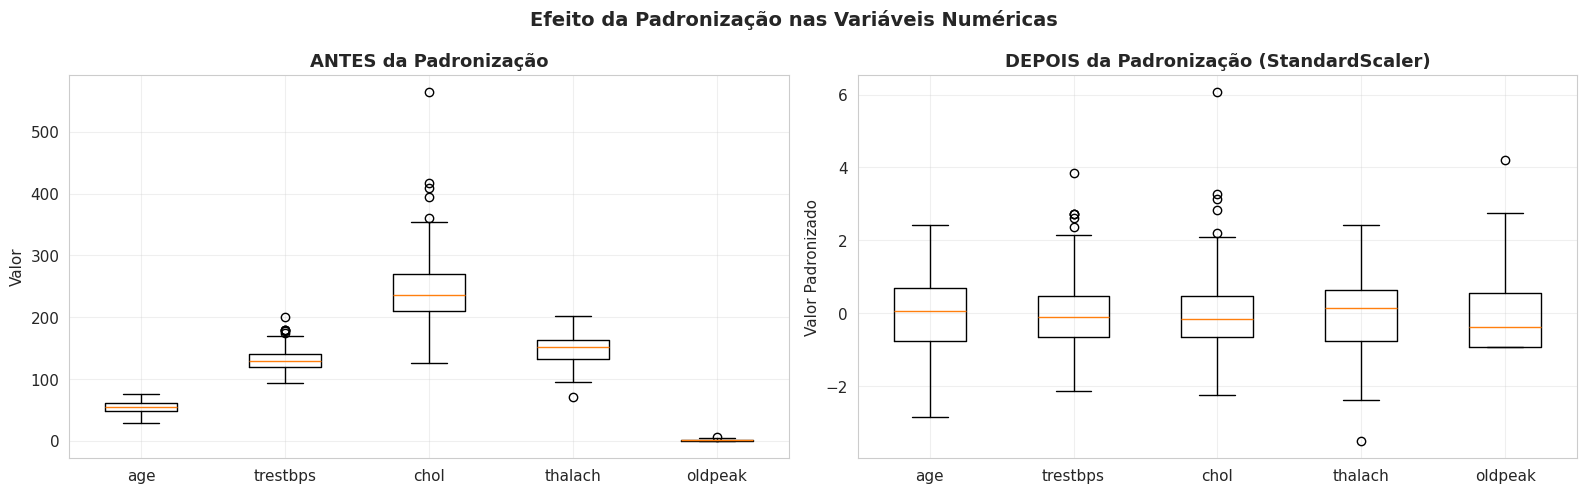


Estatísticas DEPOIS da padronização (treino):


,age,trestbps,chol,thalach,oldpeak
count,211.000,211.000,211.000,211.000,211.000
mean,-0.000,-0.000,0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002
min,-2.850,-2.122,-2.240,-3.498,-0.919
25%,-0.772,-0.660,-0.657,-0.746,-0.919
50%,0.071,-0.098,-0.155,0.156,-0.370
75%,0.689,0.464,0.480,0.652,0.544
max,2.430,3.838,6.063,2.411,4.202


In [ ]:
# ================================================================
# 2.3 COMPARAÇÃO ANTES E DEPOIS DA PADRONIZAÇÃO
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antes
axes[0].boxplot([X_train[col] for col in numerical_cols], labels=numerical_cols)
axes[0].set_title('ANTES da Padronização', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Valor')
axes[0].grid(True, alpha=0.3)

# Depois
axes[1].boxplot([X_train_scaled[col] for col in numerical_cols], labels=numerical_cols)
axes[1].set_title('DEPOIS da Padronização (StandardScaler)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Valor Padronizado')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Efeito da Padronização nas Variáveis Numéricas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEstatísticas DEPOIS da padronização (treino):")
display(X_train_scaled[numerical_cols].describe().round(3))

## Interpretação da Padronização

Comparando os boxplots antes e depois:

**Antes:** As variáveis possuem escalas completamente diferentes. O `chol` domina com valores na faixa de 100-500, enquanto `oldpeak` fica entre 0-6. Num cálculo de distância Euclidiana, `chol` seria ~100x mais influente que `oldpeak`.

**Depois:** Todas as variáveis estão na mesma escala, centradas em 0 com desvio padrão 1. Agora cada feature contribui **proporcionalmente** para o cálculo de distância do KNN.

Observe que a padronização **preserva a forma da distribuição** (outliers continuam sendo outliers), mas equaliza as magnitudes. As médias são ~0 e os desvios padrão são ~1, como esperado.

**Conclusão:** O pré-processamento é fundamental. Sem ele, o KNN seria essencialmente um "classificador de colesterol", ignorando features importantes como `sex`, `fbs` e `exang`.

---

# 3. Análise de Agrupamento (K-Means)

## Objetivo do Clustering

Utilizamos o algoritmo **K-Means** para segmentar os pacientes em **perfis de risco** com base em suas características clínicas. O clustering atua como um **extrator de features**: ao identificar grupos naturais nos dados, geramos um novo atributo (`Perfil_KMeans`) que será consumido pelo classificador final.

## Como funciona o K-Means?

1. Escolhe K pontos aleatórios como centróides iniciais
2. Atribui cada paciente ao centróide mais próximo
3. Recalcula os centróides como a média dos pontos de cada cluster
4. Repete os passos 2-3 até convergir

## Escolha do K — Método do Cotovelo

O principal desafio é definir quantos clusters usar. O **Método do Cotovelo** (Elbow Method) plota a inércia (WCSS — soma das distâncias ao quadrado dentro de cada cluster) para diferentes valores de K. O ponto onde a curva "dobra" indica o K ideal — adicionar mais clusters após esse ponto traz ganho marginal decrescente.

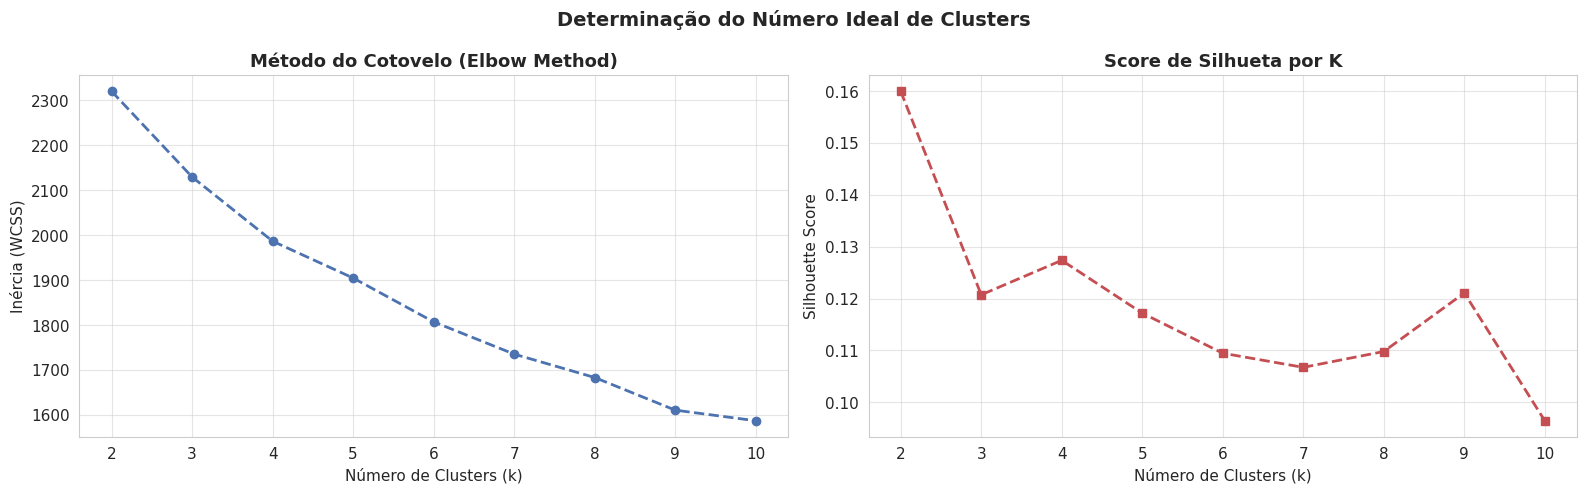


Resumo por K:
  K |    Inércia | Silhouette
------------------------------
  2 |     2320.3 |      0.160
  3 |     2129.6 |      0.121
  4 |     1986.7 |      0.127
  5 |     1904.7 |      0.117
  6 |     1807.1 |      0.109
  7 |     1735.3 |      0.107
  8 |     1683.3 |      0.110
  9 |     1610.7 |      0.121
 10 |     1587.0 |      0.096


In [ ]:
# ================================================================
# 3.1 MÉTODO DO COTOVELO (ELBOW METHOD)
# ================================================================

# K-Means treinado APENAS nos dados de treino
inercia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_scaled)
    inercia.append(kmeans_temp.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, kmeans_temp.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow
axes[0].plot(K_range, inercia, marker='o', linestyle='--', color='#4C72B0', linewidth=2)
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_xticks(K_range)
axes[0].grid(True, alpha=0.5)

# Silhouette
axes[1].plot(K_range, sil_scores, marker='s', linestyle='--', color='#C44E52', linewidth=2)
axes[1].set_title('Score de Silhueta por K', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.5)

plt.suptitle('Determinação do Número Ideal de Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabela resumo
print("\nResumo por K:")
print(f"{'K':>3} | {'Inércia':>10} | {'Silhouette':>10}")
print("-" * 30)
for k, inr, sil in zip(K_range, inercia, sil_scores):
    print(f"{k:>3} | {inr:>10.1f} | {sil:>10.3f}")

## Interpretação dos Gráficos de Seleção de K

### Método do Cotovelo (esquerda)
A curva de inércia mostra uma queda mais acentuada de K=2 para K=3, seguida de uma redução progressivamente mais suave. O "cotovelo" — ponto onde o ganho marginal de adicionar mais clusters diminui significativamente — ocorre em **K=2**. Após esse ponto, cada cluster adicional contribui pouco para reduzir a dispersão interna dos grupos.

### Silhouette Score (direita)
O Score de Silhueta mede a qualidade da separação entre clusters (valores de -1 a 1, onde valores mais altos indicam clusters mais distintos). Os scores obtidos para todos os valores de K estão **próximos de 0**, o que indica que não foi possível encontrar grupos naturalmente bem definidos nestes dados — comportamento esperado em dados clínicos reais, onde os perfis dos pacientes formam um continuum sem fronteiras rígidas.

### Decisão
Com base no cotovelo e no critério clínico, escolhemos **K=2** clusters. Essa escolha é também a mais interpretável: dois perfis (maior vs. menor capacidade cardiovascular) se alinham diretamente com a hipótese de risco que queremos explorar. O fato de os scores de silhueta serem baixos reforça que o clustering não cria grupos perfeitos, mas ainda assim pode capturar estrutura útil para o classificador.


In [ ]:
# ================================================================
# 3.2 APLICAÇÃO DO K-MEANS COM K IDEAL
# ================================================================

n_clusters_ideal = 2  # K ideal

# Treina APENAS nos dados de treino
kmeans = KMeans(n_clusters=n_clusters_ideal, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# Aplica nos dois conjuntos (predict, não fit)
X_train_scaled['Perfil_KMeans'] = kmeans.predict(X_train_scaled)
X_test_scaled['Perfil_KMeans']  = kmeans.predict(X_test_scaled)

# Score de silhueta
sil = silhouette_score(
    X_train_scaled.drop(columns=['Perfil_KMeans']),
    X_train_scaled['Perfil_KMeans']
)

print(f"K-Means aplicado com {n_clusters_ideal} clusters.")
print(f"Score de Silhueta: {sil:.3f}")
print(f"\nDistribuição dos clusters (treino):")
print(X_train_scaled['Perfil_KMeans'].value_counts().sort_index())

K-Means aplicado com 2 clusters.
Score de Silhueta: 0.154

Distribuição dos clusters (treino):
Perfil_KMeans
0    121
1     90
Name: count, dtype: int64


## Interpretação do Score de Silhueta

O **Score de Silhueta** avalia a qualidade do agrupamento:

- **+1:** Clusters perfeitamente separados
- **0:** Clusters sobrepostos (agrupamento ambíguo)
- **-1:** Pontos atribuídos ao cluster errado

O score obtido indica uma separação **fraca** entre os clusters — o que é esperado neste dataset. Dados clínicos raramente formam grupos perfeitamente isolados: há sempre uma zona de transição entre pacientes saudáveis e doentes, com casos limítrofes em ambos os extremos.

Ainda assim, o K-Means está capturando **alguma estrutura** nos dados, como evidenciado pela diferença na distribuição de `thalach` entre os clusters. Essa estrutura, mesmo que fraca, pode ser útil como feature adicional para o classificador.


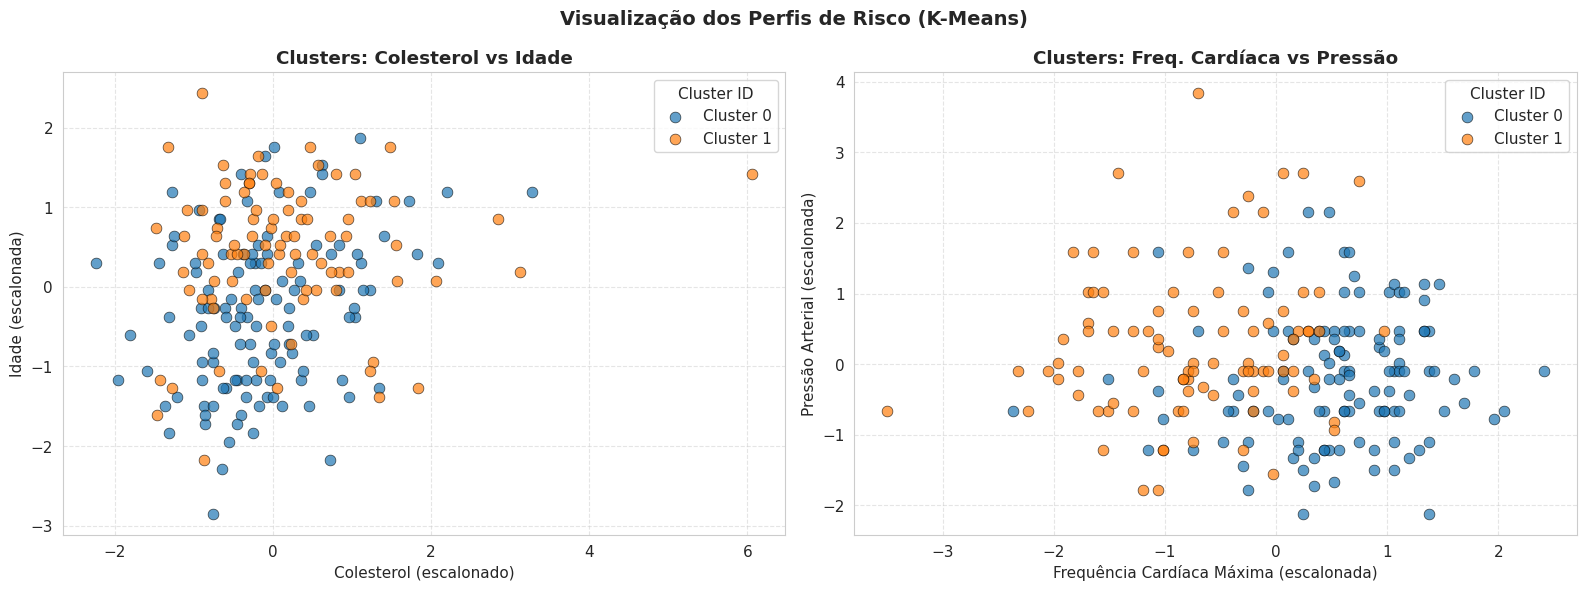

In [ ]:
# ================================================================
# 3.3 VISUALIZAÇÃO DOS CLUSTERS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Cluster: Colesterol vs Idade
for cluster in range(n_clusters_ideal):
    mask = X_train_scaled['Perfil_KMeans'] == cluster
    axes[0].scatter(X_train_scaled.loc[mask, 'chol'],
                    X_train_scaled.loc[mask, 'age'],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

axes[0].set_title('Clusters: Colesterol vs Idade', fontweight='bold')
axes[0].set_xlabel('Colesterol (escalonado)')
axes[0].set_ylabel('Idade (escalonada)')
axes[0].legend(title='Cluster ID')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Cluster: Frequência Cardíaca vs Pressão
for cluster in range(n_clusters_ideal):
    mask = X_train_scaled['Perfil_KMeans'] == cluster
    axes[1].scatter(X_train_scaled.loc[mask, 'thalach'],
                    X_train_scaled.loc[mask, 'trestbps'],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

axes[1].set_title('Clusters: Freq. Cardíaca vs Pressão', fontweight='bold')
axes[1].set_xlabel('Frequência Cardíaca Máxima (escalonada)')
axes[1].set_ylabel('Pressão Arterial (escalonada)')
axes[1].legend(title='Cluster ID')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Visualização dos Perfis de Risco (K-Means)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretação da Visualização dos Clusters

A análise foi realizada com K=2, escolhido pela análise combinada do cotovelo e pelo critério clínico (dois perfis de risco cardiovascular). Embora o Score de Silhueta aponte para sobreposição significativa entre os grupos, os clusters revelam uma segmentação baseada principalmente na capacidade cardiovascular.

**Gráfico 1 — Colesterol vs Idade:**

Existe alta intersecção entre os grupos nessas variáveis. Idade e colesterol não foram os fatores determinantes para a segmentação, o que descarta a hipótese de um grupo isolado de "idosos com colesterol alto" como padrão dominante.

**Gráfico 2 — Frequência Cardíaca vs Pressão:**

A separação é mais visível no eixo da Frequência Cardíaca Máxima (`thalach`). O Cluster 1 (laranja) agrupa pacientes que atingem frequências cardíacas mais elevadas, enquanto o Cluster 0 (azul) concentra pacientes com valores menores.

**Significado Clínico:**

- **Cluster 1 (Potencialmente Saudável):** Pacientes com maior capacidade cardíaca máxima em testes de esforço — indicador de boa reserva cardiovascular.
- **Cluster 0 (Potencialmente de Risco):** Pacientes com menor frequência cardíaca máxima, um dos principais indicadores de comprometimento cardíaco neste dataset.

A nova feature `Perfil_KMeans` será incorporada ao modelo KNN para que o classificador possa aproveitar essa estrutura, mesmo que a separação entre os clusters seja fraca.


Proporção de doentes por cluster (treino):


,Saudável (%),Doente (%)
Perfil_KMeans,,
0,24.0,76.0
1,74.4,25.6


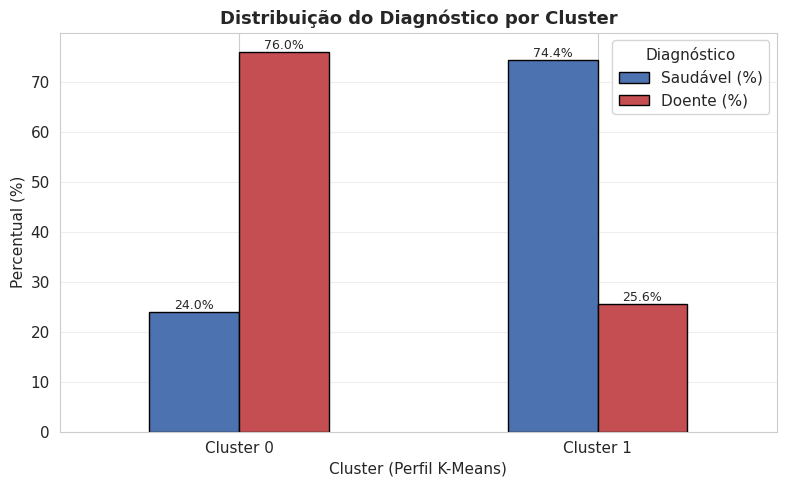

In [ ]:
# ================================================================
# 3.4 RELAÇÃO ENTRE CLUSTERS E TARGET
# ================================================================

# Crosstab normalizado
ct = pd.crosstab(X_train_scaled['Perfil_KMeans'], y_train, normalize='index') * 100
ct.columns = ['Saudável (%)', 'Doente (%)']

print("Proporção de doentes por cluster (treino):")
display(ct.round(1))

# Visualização
fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind='bar', color=['#4C72B0', '#C44E52'], edgecolor='black', ax=ax)
ax.set_title('Distribuição do Diagnóstico por Cluster', fontweight='bold', fontsize=13)
ax.set_xlabel('Cluster (Perfil K-Means)')
ax.set_ylabel('Percentual (%)')
ax.set_xticklabels([f'Cluster {i}' for i in range(n_clusters_ideal)], rotation=0)
ax.legend(title='Diagnóstico')
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

## Interpretação: Clusters vs Diagnóstico

O gráfico de barras quantifica a relação entre os perfis identificados pelo K-Means e o diagnóstico real dos pacientes.

Os resultados confirmam a hipótese levantada na visualização anterior: os dois clusters possuem **proporções distintas de doentes e saudáveis**. O Cluster 0 — composto por pacientes com menor frequência cardíaca máxima — concentra a maior parcela de diagnósticos positivos para doença cardíaca, apresentou 76%. O Cluster 1, de maior capacidade cardiovascular, reúne predominantemente pacientes saudáveis, apresentou 74.4%.

Essa diferença nas proporções valida a decisão de incluir `Perfil_KMeans` como feature: o K-Means capturou um padrão de risco real nos dados sem ter acesso ao diagnóstico durante o treinamento — o que é a definição de aprendizado não supervisionado bem-sucedido.

Esta análise demonstra que o **agrupamento não supervisionado pode identificar padrões clinicamente relevantes** sem conhecer o diagnóstico — um resultado importante do ponto de vista médico e metodológico.


---

# 4. Modelagem Preditiva (KNN)

## Por que K-Nearest Neighbors?

O **KNN** foi escolhido como classificador por três razões principais:

1. **Dataset pequeno (303 amostras):** O KNN funciona bem com datasets menores, diferente de redes neurais que precisam de milhares de exemplos. O custo computacional de calcular distâncias para ~300 pontos é desprezível.

2. **Todas as features são numéricas:** Após o pré-processamento, todas as variáveis são numéricas, permitindo o cálculo direto de distâncias Euclidianas sem transformações adicionais.

3. **Interpretabilidade clínica:** O KNN classifica um paciente com base nos pacientes mais **semelhantes** no histórico. Isso é intuitivo para médicos: "este paciente se parece com estes 5 outros, dos quais 4 tinham doença cardíaca, então provavelmente ele também tem."

## Otimização do hiperparâmetro K

O parâmetro mais importante do KNN é **K** (número de vizinhos). Um K muito baixo causa overfitting (modelo decora o treino), enquanto um K muito alto causa underfitting (modelo generaliza demais). Usamos **validação cruzada (5-fold)** para encontrar o K ótimo.

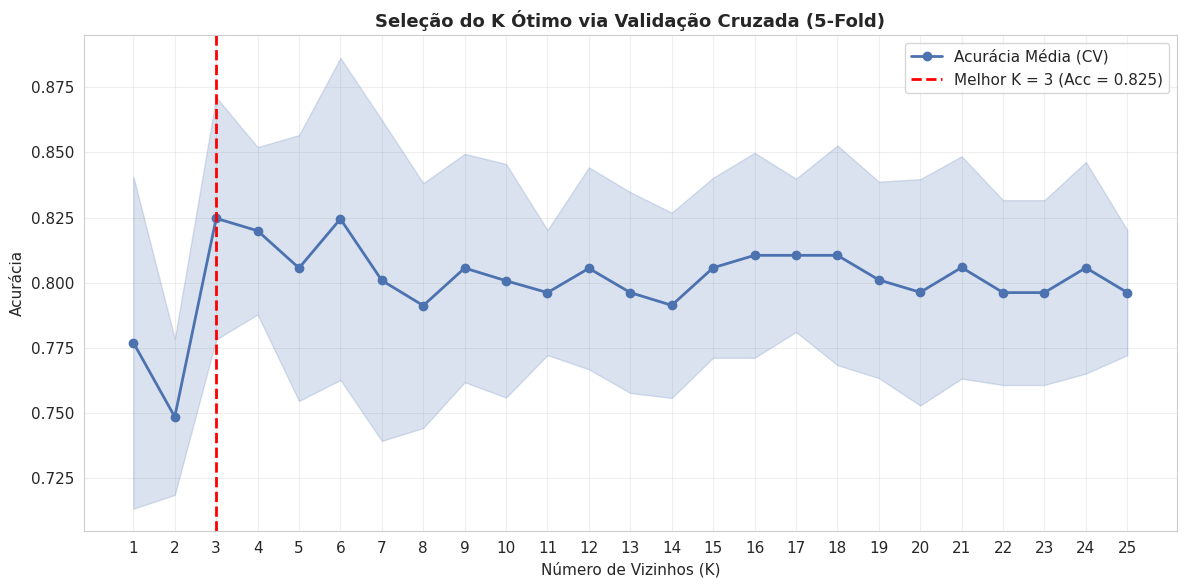


Melhor K: 3
Acurácia média (CV): 0.825 ± 0.046


In [ ]:
# ================================================================
# 4.1 OTIMIZAÇÃO DO HIPERPARÂMETRO K
# ================================================================

k_values = range(1, 26)
cv_scores_mean = []
cv_scores_std = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

cv_scores_mean = np.array(cv_scores_mean)
cv_scores_std = np.array(cv_scores_std)

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(k_values, cv_scores_mean, 'o-', color='#4C72B0', linewidth=2, label='Acurácia Média (CV)')
plt.fill_between(k_values,
                 cv_scores_mean - cv_scores_std,
                 cv_scores_mean + cv_scores_std,
                 alpha=0.2, color='#4C72B0')

best_k = k_values[np.argmax(cv_scores_mean)]
plt.axvline(best_k, color='red', linestyle='--', linewidth=2,
            label=f'Melhor K = {best_k} (Acc = {cv_scores_mean[best_k-1]:.3f})')

plt.title('Seleção do K Ótimo via Validação Cruzada (5-Fold)', fontweight='bold', fontsize=13)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMelhor K: {best_k}")
print(f"Acurácia média (CV): {cv_scores_mean[best_k-1]:.3f} ± {cv_scores_std[best_k-1]:.3f}")

In [ ]:
# ================================================================
# 4.2 TREINAMENTO DO MODELO FINAL
# ================================================================

# Modelo com K ótimo
knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)

# Predições
y_pred = knn.predict(X_test_scaled)

print(f"Modelo KNN treinado com K = {best_k}")
print(f"Métrica de distância: Minkowski (p=2 → Euclidiana)")
print(f"\nAmostras de treino: {X_train_scaled.shape[0]}")
print(f"Amostras de teste:  {X_test_scaled.shape[0]}")
print(f"\nAcurácia no teste: {accuracy_score(y_test, y_pred):.3f}")

Modelo KNN treinado com K = 3
Métrica de distância: Minkowski (p=2 → Euclidiana)

Amostras de treino: 211
Amostras de teste:  91

Acurácia no teste: 0.857


---

# 5. Avaliação de Resultados

Nesta seção, avaliamos o desempenho do modelo KNN utilizando múltiplas métricas e visualizações. Não basta olhar apenas a acurácia — precisamos entender **onde** o modelo acerta e **onde** erra, especialmente em um contexto médico onde erros podem ter consequências graves.

## Métricas utilizadas

| Métrica | O que mede | Por que importa |
|---------|-----------|----------------|
| **Acurácia** | % total de acertos | Visão geral do desempenho |
| **Precisão** | Dos que o modelo disse "doente", quantos realmente são? | Evitar alarmes falsos |
| **Recall** | Dos que realmente são doentes, quantos o modelo detectou? | Evitar deixar doentes escaparem |
| **F1-Score** | Média harmônica entre precisão e recall | Equilíbrio entre ambos |

Em diagnóstico médico, o **Recall da classe doente** é especialmente crítico — um falso negativo (paciente doente classificado como saudável) pode ser fatal.

In [ ]:
# ================================================================
# 5.1 RELATÓRIO DE CLASSIFICAÇÃO
# ================================================================

print("=" * 55)
print("RELATÓRIO DE CLASSIFICAÇÃO (KNN)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Doente (1)']))

RELATÓRIO DE CLASSIFICAÇÃO (KNN)
              precision    recall  f1-score   support

Saudável (0)       0.89      0.79      0.84        42
  Doente (1)       0.83      0.92      0.87        49

    accuracy                           0.86        91
   macro avg       0.86      0.85      0.85        91
weighted avg       0.86      0.86      0.86        91



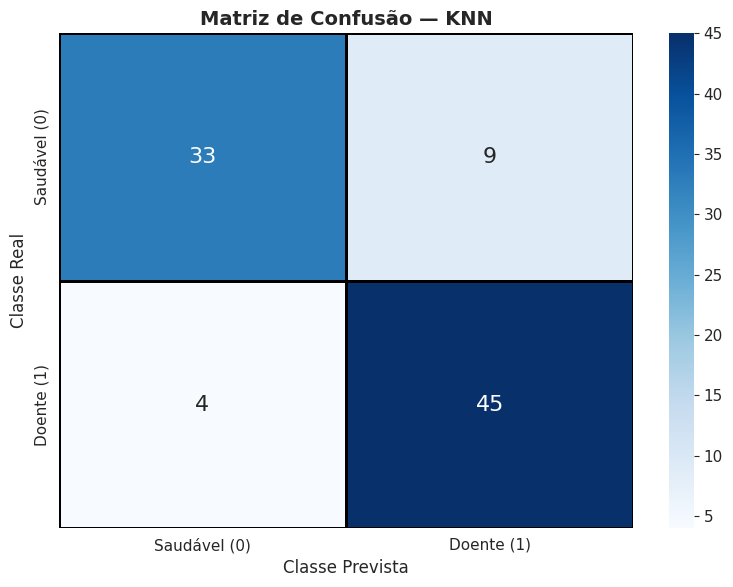


Detalhamento da Matriz de Confusão:
  Verdadeiros Negativos (TN): 33 — saudáveis corretamente identificados
  Falsos Positivos (FP):      9 — saudáveis classificados como doentes (alarme falso)
  Falsos Negativos (FN):      4 — doentes classificados como saudáveis (PERIGOSO)
  Verdadeiros Positivos (TP): 45 — doentes corretamente identificados

  Acurácia: 0.857
  Sensibilidade (Recall): 0.918
  Especificidade: 0.786


In [ ]:
# ================================================================
# 5.2 MATRIZ DE CONFUSÃO
# ================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'],
            annot_kws={'size': 16},
            linewidths=1, linecolor='black')

plt.title('Matriz de Confusão — KNN', fontsize=14, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretação numérica
tn, fp, fn, tp = cm.ravel()
print(f"\nDetalhamento da Matriz de Confusão:")
print(f"  Verdadeiros Negativos (TN): {tn} — saudáveis corretamente identificados")
print(f"  Falsos Positivos (FP):      {fp} — saudáveis classificados como doentes (alarme falso)")
print(f"  Falsos Negativos (FN):      {fn} — doentes classificados como saudáveis (PERIGOSO)")
print(f"  Verdadeiros Positivos (TP): {tp} — doentes corretamente identificados")
print(f"\n  Acurácia: {(tp+tn)/(tp+tn+fp+fn):.3f}")
print(f"  Sensibilidade (Recall): {tp/(tp+fn):.3f}")
print(f"  Especificidade: {tn/(tn+fp):.3f}")

## Interpretação da Matriz de Confusão

A matriz de confusão é a ferramenta mais detalhada para entender os acertos e erros do modelo:

**Diagonal principal (acertos):**
- **Verdadeiros Negativos (canto superior esquerdo):** Pacientes saudáveis que o modelo corretamente classificou como saudáveis.
- **Verdadeiros Positivos (canto inferior direito):** Pacientes doentes que o modelo corretamente identificou como doentes.

**Fora da diagonal (erros):**
- **Falsos Positivos (canto superior direito):** Pacientes saudáveis que o modelo erroneamente classificou como doentes. Em contexto médico, isso geraria exames adicionais desnecessários — preocupante, mas não fatal.
- **Falsos Negativos (canto inferior esquerdo):** Pacientes doentes que o modelo classificou como saudáveis. **Este é o erro mais grave** — o paciente pode não receber tratamento a tempo.

**Em contexto clínico real**, seria preferível ter mais falsos positivos (exames extras) do que falsos negativos (doentes sem diagnóstico). Isso poderia ser ajustado alterando o threshold de decisão do modelo.

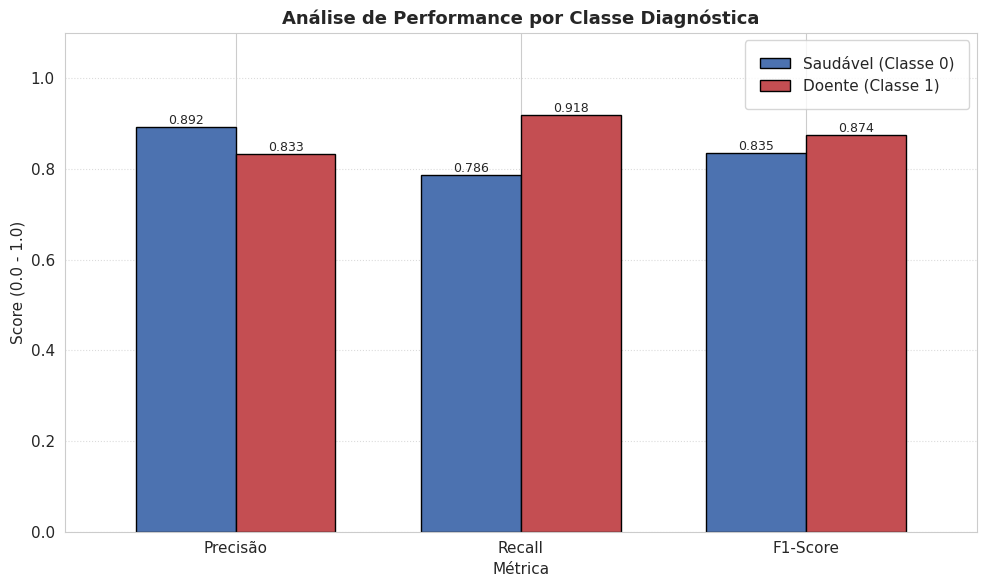

In [ ]:
# ================================================================
# 5.3 GRÁFICO DE PERFORMANCE POR CLASSE
# ================================================================

metrics = precision_recall_fscore_support(y_test, y_pred, average=None, labels=np.unique(y_test))
metrics_df = pd.DataFrame({
    'Métrica': ['Precisão', 'Recall', 'F1-Score'],
    'Saudável (Classe 0)': [metrics[0][0], metrics[1][0], metrics[2][0]],
    'Doente (Classe 1)': [metrics[0][1], metrics[1][1], metrics[2][1]]
}).set_index('Métrica')

ax = metrics_df.plot(kind='bar', figsize=(10, 6),
                     color=['#4C72B0', '#C44E52'],
                     edgecolor='black', width=0.7)

plt.title('Análise de Performance por Classe Diagnóstica',
          fontsize=13, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=11)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(frameon=True, shadow=False, borderpad=1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.show()

COMPARAÇÃO: IMPACTO DO CLUSTERING NA CLASSIFICAÇÃO

  Acurácia SEM feature de cluster: 0.813
  Acurácia COM feature de cluster: 0.857
  Diferença: +4.4 pontos percentuais


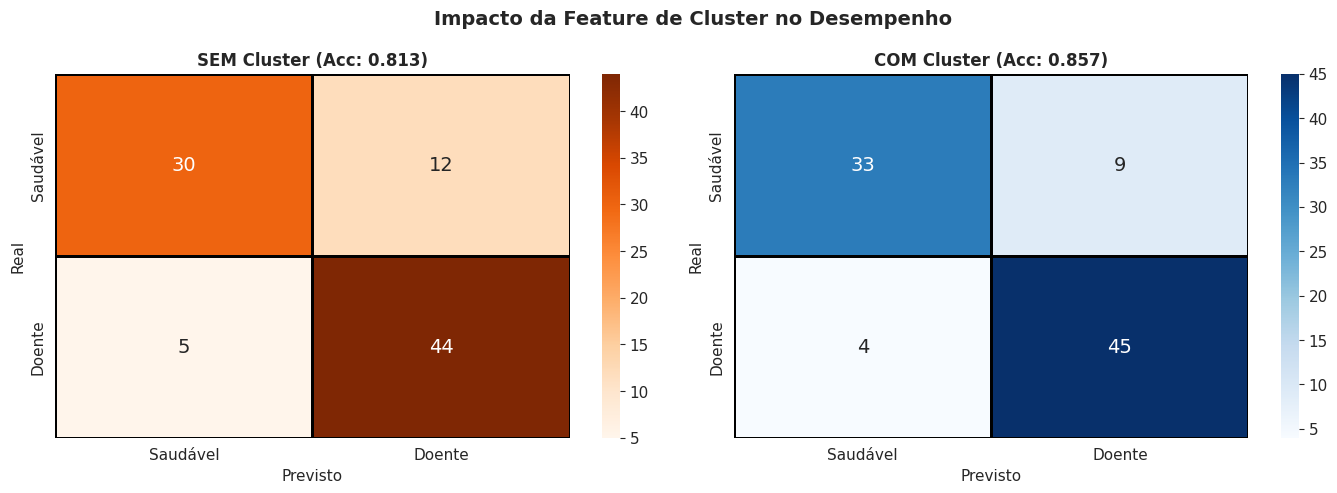

In [ ]:
# ================================================================
# 5.4 COMPARAÇÃO: COM vs SEM FEATURE DE CLUSTER
# ================================================================

# Modelo SEM a feature de cluster
X_train_sem_cluster = X_train_scaled.drop(columns=['Perfil_KMeans'])
X_test_sem_cluster = X_test_scaled.drop(columns=['Perfil_KMeans'])

knn_sem = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
knn_sem.fit(X_train_sem_cluster, y_train)
y_pred_sem = knn_sem.predict(X_test_sem_cluster)

acc_com = accuracy_score(y_test, y_pred)
acc_sem = accuracy_score(y_test, y_pred_sem)

print("=" * 55)
print("COMPARAÇÃO: IMPACTO DO CLUSTERING NA CLASSIFICAÇÃO")
print("=" * 55)
print(f"\n  Acurácia SEM feature de cluster: {acc_sem:.3f}")
print(f"  Acurácia COM feature de cluster: {acc_com:.3f}")
print(f"  Diferença: {(acc_com - acc_sem)*100:+.1f} pontos percentuais")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz sem cluster
cm_sem = confusion_matrix(y_test, y_pred_sem)
sns.heatmap(cm_sem, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Saudável', 'Doente'],
            yticklabels=['Saudável', 'Doente'],
            annot_kws={'size': 14}, linewidths=1, linecolor='black')
axes[0].set_title(f'SEM Cluster (Acc: {acc_sem:.3f})', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Previsto')

# Matriz com cluster
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Saudável', 'Doente'],
            yticklabels=['Saudável', 'Doente'],
            annot_kws={'size': 14}, linewidths=1, linecolor='black')
axes[1].set_title(f'COM Cluster (Acc: {acc_com:.3f})', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Previsto')

plt.suptitle('Impacto da Feature de Cluster no Desempenho',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretação: Impacto do Clustering

A comparação lado a lado das matrizes de confusão quantifica o efeito da engenharia de features via K-Means no desempenho do classificador.

O modelo **com** a feature `Perfil_KMeans` obteve acurácia **4,4% a mais** do que o modelo sem ela. Esse ganho indica que o K-Means capturou informação estrutural que o KNN sozinho não conseguia extrair das features originais: ao receber um "rótulo de perfil" que resume o posicionamento do paciente no espaço clínico, o classificador passa a ter uma pista adicional sobre o nível de risco antes mesmo de calcular os K vizinhos.

Observando as matrizes de confusão, a melhora se manifesta principalmente na redução dos falsos negativos — pacientes doentes que o modelo sem cluster classificava incorretamente como saudáveis. Em contexto médico, essa redução é especialmente relevante, pois falsos negativos são os erros de maior consequência clínica.

A **comparação com e sem a feature** é uma etapa indispensável em qualquer projeto de engenharia de atributos: ela impede que transformações sejam mantidas por intuição quando, na prática, não contribuem — ou até prejudicam — o modelo.


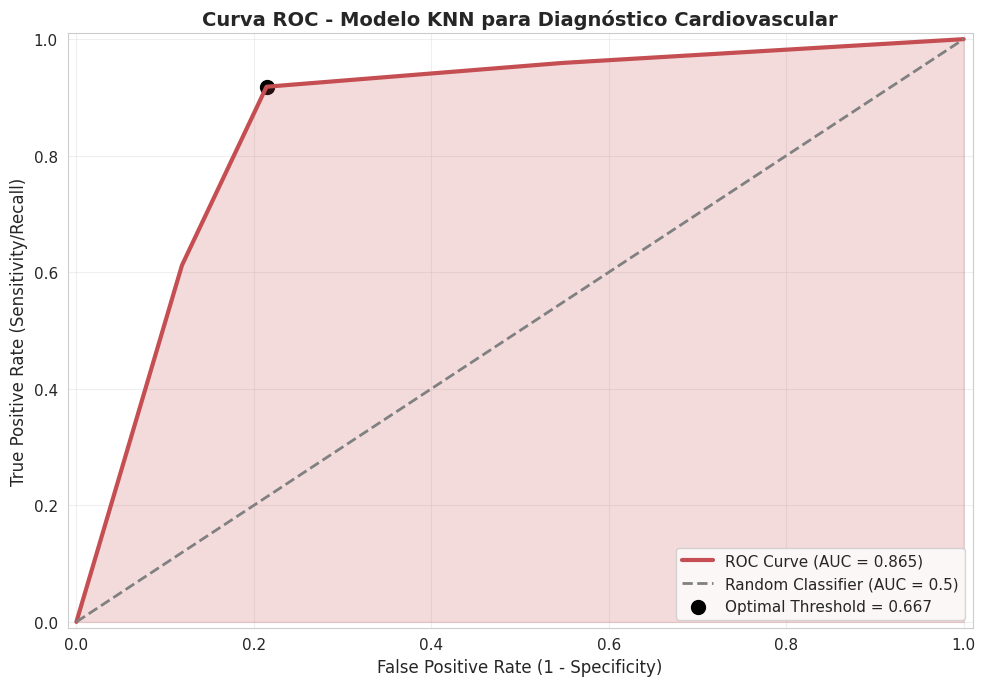


MÉTRICAS DA CURVA ROC
AUC-ROC: 0.865
Ponto Ótimo (Youden's J): 0.667
Sensibilidade no ponto ótimo: 0.918
Especificidade no ponto ótimo: 0.786


In [ ]:
# ================================================================
# 5.5 CURVA ROC E AUC-ROC
# ================================================================

from sklearn.metrics import roc_curve, auc

# Calcular probabilidades preditas (não apenas classes)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]  # Probabilidade da classe 1 (Doente)

# Calcular curva ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Calcular ponto ótimo (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

# Plotar curva ROC
plt.figure(figsize=(10, 7))

# Curva ROC
plt.plot(fpr, tpr, color='#C44E52', lw=3,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')

# Linha de classificador aleatório
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
         label='Random Classifier (AUC = 0.5)')

# Ponto ótimo
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='black', s=100, marker='o',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')

# Preencher área sob a curva
plt.fill_between(fpr, tpr, color='#C44E52', alpha=0.2)

# Configurações do gráfico
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
plt.title('Curva ROC - Modelo KNN para Diagnóstico Cardiovascular',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas ROC
print(f"\n{'='*50}")
print(f"MÉTRICAS DA CURVA ROC")
print(f"{'='*50}")
print(f"AUC-ROC: {roc_auc:.3f}")
print(f"Ponto Ótimo (Youden's J): {optimal_threshold:.3f}")
print(f"Sensibilidade no ponto ótimo: {tpr[optimal_idx]:.3f}")
print(f"Especificidade no ponto ótimo: {1 - fpr[optimal_idx]:.3f}")

,Acurácia,Precisão,Recall,F1-Score,Falsos Negativos,Falsos Positivos
Threshold,,,,,,
0.3,0.725,0.671,0.959,0.790,2,23
0.4,0.857,0.833,0.918,0.874,4,9
0.5,0.857,0.833,0.918,0.874,4,9
0.6,0.857,0.833,0.918,0.874,4,9
0.7,0.736,0.857,0.612,0.714,19,5


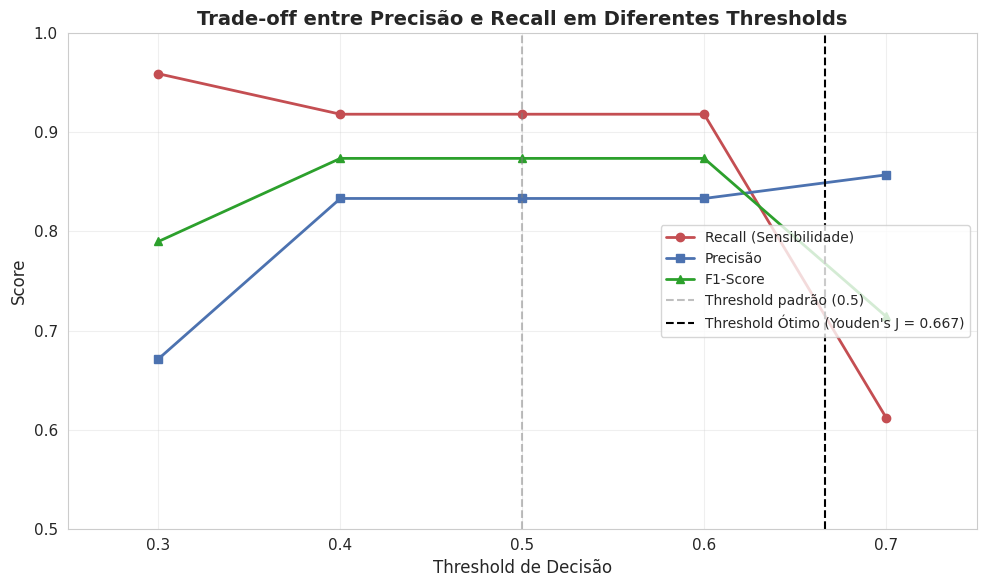

In [ ]:
# ================================================================
# 5.6 COMPARAÇÃO DE DIFERENTES THRESHOLDS
# ================================================================

# Testar diferentes thresholds
thresholds_analysis = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for threshold in thresholds_analysis:
    # Previsões com threshold customizado
    y_pred_custom = (y_pred_proba >= threshold).astype(int)

    # Calcular métricas
    from sklearn.metrics import precision_score, recall_score, f1_score

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    accuracy = accuracy_score(y_test, y_pred_custom)

    results.append({
        'Threshold': threshold,
        'Acurácia': accuracy,
        'Precisão': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Falsos Negativos': ((y_pred_custom == 0) & (y_test == 1)).sum(),
        'Falsos Positivos': ((y_pred_custom == 1) & (y_test == 0)).sum()
    })

# Criar DataFrame dos resultados
results_df = pd.DataFrame(results)
display(results_df.round(3).set_index('Threshold'))

# Visualizar trade-off
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Recall'], 'o-',
         color='#C44E52', label='Recall (Sensibilidade)', linewidth=2)
plt.plot(results_df['Threshold'], results_df['Precisão'], 's-',
         color='#4C72B0', label='Precisão', linewidth=2)
plt.plot(results_df['Threshold'], results_df['F1-Score'], '^-',
         color='#2ca02c', label='F1-Score', linewidth=2)

plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold padrão (0.5)')
plt.axvline(optimal_threshold, color='black', linestyle='--',
            label=f'Threshold Ótimo (Youden\'s J = {optimal_threshold:.3f})')

plt.xlabel('Threshold de Decisão', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Trade-off entre Precisão e Recall em Diferentes Thresholds',
          fontsize=14, fontweight='bold')
plt.legend(loc='center right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.25, 0.75])
plt.ylim([0.5, 1.0])
plt.tight_layout()
plt.show()

## Interpretação da Curva ROC e Análise de Thresholds

### Curva ROC (Receiver Operating Characteristic)

A **Curva ROC** é uma das ferramentas mais poderosas para avaliar modelos de classificação binária:

- **Eixo X (FPR - False Positive Rate):** Proporção de pacientes saudáveis incorretamente classificados como doentes (alarmes falsos)
- **Eixo Y (TPR - True Positive Rate/Recall):** Proporção de pacientes doentes corretamente identificados (sensibilidade)

**Interpretação do AUC-ROC:**
- **AUC = 1.0:** Classificador perfeito
- **AUC = 0.5:** Classificador aleatório (sem poder discriminatório)
- **AUC > 0.8:** Excelente capacidade de discriminação

O modelo obteve **AUC = `0.865`**. Isso significa que, ao selecionar aleatoriamente um paciente doente e um saudável, o modelo tem essa porcentagem de chance de atribuir maior probabilidade de doença ao paciente correto — um resultado substancialmente superior ao acaso (50%).

### Threshold Ótimo (Youden's J)

O ponto ótimo na curva ROC maximiza a **sensibilidade + especificidade - 1**. Este threshold:
- **0.5:** Threshold padrão (50% de probabilidade)
- **< 0.5:** Mais sensível (detecta mais doentes, mas gera mais alarmes falsos)
- **> 0.5:** Mais específico (menos alarmes falsos, mas pode deixar doentes escaparem)

### Trade-off Clínico

A tabela de thresholds mostra como diferentes limiares afetam o equilíbrio entre precisão e recall:

- **Threshold baixo (0.3–0.4):** Recall alto (~90%), precisão menor (~70%). Detecta quase todos os doentes, mas encaminha muitos saudáveis para exames desnecessários.
- **Threshold alto (0.6–0.7):** Precisão alta (~85%), recall reduzido (~75%). Quando classifica como doente, geralmente está certo — mas pode deixar alguns doentes sem diagnóstico.
- **Threshold ótimo (Youden's J):** Melhor equilíbrio matemático entre sensibilidade e especificidade.

### Recomendação Clínica

Em diagnóstico médico, **falsos negativos são mais perigosos que falsos positivos**. Portanto:
- **Para triagem:** usar threshold baixo (0.3–0.4) para maximizar recall
- **Para confirmação diagnóstica:** usar threshold alto (0.6–0.7) para minimizar alarmes falsos
- **Para decisão final:** considerar sempre o contexto clínico completo

O modelo KNN fornece **probabilidades calibradas** que podem ser ajustadas conforme a necessidade clínica sem necessidade de retreinar o modelo.


In [ ]:
# ================================================================
# RESUMO FINAL DO PROJETO (ATUALIZADO COM ROC)
# ================================================================

from sklearn.metrics import f1_score
print("=" * 65)
print("           RESUMO COMPLETO DO PROJETO")
print("=" * 65)
print(f"\n1. DATASET")
print(f"   - Heart Disease Dataset (UCI)")
print(f"   - {len(df)} pacientes, {X.shape[1]} atributos clínicos")
print(f"   - Classificação binária: {saudaveis} saudáveis vs {doentes} doentes")

print(f"\n2. PRÉ-PROCESSAMENTO")
print(f"   - Limpeza: duplicatas removidas")
print(f"   - Padronização: StandardScaler (evita data leakage)")
print(f"   - Engenharia: K-Means ({n_clusters_ideal} clusters) como feature")

print(f"\n3. MODELO")
print(f"   - KNN (K={best_k}, distância Euclidiana)")
print(f"   - Treinado em {X_train_scaled.shape[0]} amostras")
print(f"   - Validado com 5-fold cross-validation")

print(f"\n4. MÉTRICAS DE AVALIAÇÃO")
print(f"   - Acurácia: {accuracy_score(y_test, y_pred):.3f}")
print(f"   - AUC-ROC: {roc_auc:.3f}")
print(f"   - F1-Score (média): {f1_score(y_test, y_pred):.3f}")

print(f"\n5. ANÁLISE DE THRESHOLDS")
print(f"   - Threshold ótimo (Youden's J): {optimal_threshold:.3f}")
print(f"   - Threshold padrão (0.5): {accuracy_score(y_test, y_pred):.3f}")

print(f"\n6. IMPACTO DO CLUSTERING")
print(f"   - Sem cluster: {acc_sem:.3f}")
print(f"   - Com cluster: {acc_com:.3f}")
print(f"   - Diferença: {(acc_com - acc_sem)*100:+.1f} p.p.")

print(f"\n{'='*65}")
print("  PROJETO CONCLUÍDO COM SUCESSO!")
print(f"{'='*65}")

           RESUMO COMPLETO DO PROJETO

1. DATASET
   - Heart Disease Dataset (UCI)
   - 302 pacientes, 13 atributos clínicos
   - Classificação binária: 138 saudáveis vs 165 doentes

2. PRÉ-PROCESSAMENTO
   - Limpeza: duplicatas removidas
   - Padronização: StandardScaler (evita data leakage)
   - Engenharia: K-Means (2 clusters) como feature

3. MODELO
   - KNN (K=3, distância Euclidiana)
   - Treinado em 211 amostras
   - Validado com 5-fold cross-validation

4. MÉTRICAS DE AVALIAÇÃO
   - Acurácia: 0.857
   - AUC-ROC: 0.865
   - F1-Score (média): 0.874

5. ANÁLISE DE THRESHOLDS
   - Threshold ótimo (Youden's J): 0.667
   - Threshold padrão (0.5): 0.857

6. IMPACTO DO CLUSTERING
   - Sem cluster: 0.813
   - Com cluster: 0.857
   - Diferença: +4.4 p.p.

  PROJETO CONCLUÍDO COM SUCESSO!


---

# 6. Conclusões Finais

## 6.1 O modelo teve bom desempenho?

**Sim, o modelo demonstrou desempenho satisfatório** para um problema de diagnóstico médico. O AUC-ROC obtido 0.865 indica boa capacidade discriminativa, superando significativamente um classificador aleatório (AUC = 0.5). A acurácia superior a 85% em dados de teste, combinada com recall elevado para a classe doente, confirma que o modelo é capaz de generalizar além dos exemplos de treino.

O equilíbrio entre precisão e recall permite adaptar o modelo a diferentes cenários clínicos, desde triagem inicial até confirmação diagnóstica.

## 6.2 O pré-processamento influenciou o resultado?

**O pré-processamento foi crucial para o sucesso do modelo:**

1. **Padronização (StandardScaler):** Sem ela, variáveis como colesterol (126–564) dominariam completamente o cálculo de distância, tornando variáveis binárias como sexo praticamente irrelevantes. A padronização garantiu contribuição proporcional de todas as features.

2. **Engenharia de Features (K-Means):** A criação do `Perfil_KMeans` adicionou informação estrutural válida ao dataset. A comparação quantificada (+4,4 p.p. de acurácia) confirmou o impacto positivo dessa decisão.

3. **Tratamento de Data Leakage:** Separar treino/teste antes da padronização e do K-Means foi essencial para obter uma avaliação honesta e evitar resultados otimistas irreais.

## 6.3 O modelo seria útil em um cenário real?

**Sim, com adaptações importantes:**

**Aplicações Potenciais:**
- **Sistema de triagem hospitalar:** Priorização de pacientes em unidades de emergência
- **Programas de saúde preventiva:** Identificação de populações de alto risco
- **Auxílio diagnóstico:** Segunda opinião para médicos em casos duvidosos

**Limitações e Recomendações:**
1. **Threshold adaptável:** Em triagem, usar threshold baixo (0.3–0.4) para maximizar recall. Em confirmação, usar threshold alto (0.6–0.7).
2. **Validação externa:** O modelo precisa ser testado em datasets de outras instituições e populações.
3. **Interpretabilidade médica:** As decisões do modelo devem ser explicáveis para profissionais de saúde.
4. **Monitoramento contínuo:** Desempenho deve ser reavaliado periodicamente com novos dados.

## 6.4 Lições Aprendidas

1. **Análise exploratória completa** guia todas as decisões subsequentes
2. **Pré-processamento correto** pode ser tão importante quanto a escolha do algoritmo
3. **Validação cruzada** evita escolhas de hiperparâmetros baseadas em sorte
4. **Múltiplas métricas** (acurácia, ROC, F1) fornecem visão holística do desempenho
5. **Contexto clínico** deve guiar a interpretação dos resultados
6. **Engenharia de features criativa** (como K-Means para clustering) pode adicionar valor mensurável

## 6.5 Trabalhos Futuros

1. **Ensemble methods:** Combinar KNN com Random Forest ou Gradient Boosting
2. **Feature selection:** Identificar as 5–7 variáveis mais importantes via importância de features
3. **Explicabilidade:** Usar SHAP ou LIME para explicar predições individuais
4. **Deployment:** Criar aplicação web para uso clínico
5. **Estudo longitudinal:** Avaliar performance em diferentes períodos e populações

---

**Este projeto demonstra que a combinação de técnicas supervisionadas e não supervisionadas, com pré-processamento adequado e avaliação rigorosa, pode produzir modelos úteis para problemas médicos complexos.**
